# Telemetry EDA
  
**Dataset:** `data/w03_rover_5units_1day`  

This notebook performs the EDA for the Week 3 synthetic Aido Rover telemetry sample:

1. data loading and manifest validation  
2. ADF stationarity tests  
3. STL seasonality decomposition  
4. pairwise correlation structure  
5. missingness pattern analysis  

In [1]:
from pathlib import Path
import gzip
import hashlib
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Python environment ready.")

Python environment ready.


## 1. Locate and Load Data

In [2]:
def find_dataset():
    """Find the Week 3 medium telemetry sample in common local and sandbox layouts."""
    candidates = [
        Path("../data/w03_rover_5units_1day"),  # notebook inside week03_telemetry/
        Path("data/w03_rover_5units_1day"),     # notebook at repo root
        Path("/mnt/data"),                       # uploaded-file sandbox fallback
    ]

    for base in candidates:
        if not base.exists():
            continue

        recursive_files = sorted(base.glob("robot_id=*/day=*/telemetry.csv.gz"))
        flat_files = sorted(base.glob("telemetry*.csv.gz"))

        if recursive_files:
            return base, recursive_files, base / "manifest.json"
        if flat_files:
            return base, flat_files, base / "manifest.json"

    raise FileNotFoundError(
        "Could not find telemetry files. Expected data/w03_rover_5units_1day or uploaded telemetry*.csv.gz files."
    )


DATA_BASE, TELEMETRY_FILES, MANIFEST_PATH = find_dataset()

print("Data base:", DATA_BASE)
print("Telemetry files found:", len(TELEMETRY_FILES))
for p in TELEMETRY_FILES[:10]:
    print(" -", p)
print("Manifest path:", MANIFEST_PATH if MANIFEST_PATH.exists() else "not found")

Data base: /mnt/data
Telemetry files found: 1
 - /mnt/data/telemetry.csv.gz
Manifest path: /mnt/data/manifest.json


In [3]:
def sha256_file(path: Path) -> str:
    """Compute SHA-256 digest for one file."""
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


manifest = None
if MANIFEST_PATH.exists():
    with MANIFEST_PATH.open("r", encoding="utf-8") as f:
        manifest = json.load(f)

    print("Manifest loaded.")
    print(json.dumps(manifest.get("estimate", {}), indent=2))
else:
    print("Manifest not found. Proceeding with available telemetry files only.")

Manifest loaded.
{
  "fleet_size": 5,
  "format": "csv.gz",
  "freq_hz": 1.0,
  "horizon_days": 1.0,
  "output_dir": "data/w03_rover_5units_1day",
  "partitions": 5,
  "ticks_per_robot": 86400,
  "total_rows": 432000
}


In [4]:
# Load all partitions. The medium sample is 432,000 rows, which is practical for local EDA.
frames = []
file_summaries = []

for p in TELEMETRY_FILES:
    df_part = pd.read_csv(p, parse_dates=["timestamp"])
    frames.append(df_part)

    robot = df_part["robot_id"].iloc[0] if "robot_id" in df_part.columns and len(df_part) else "unknown"
    file_summaries.append({
        "file": str(p),
        "robot_id": robot,
        "rows": len(df_part),
        "sha256": sha256_file(p),
    })

df = pd.concat(frames, ignore_index=True)
df = df.sort_values(["robot_id", "timestamp"]).reset_index(drop=True)

file_summary_df = pd.DataFrame(file_summaries).sort_values("robot_id").reset_index(drop=True)

print("Combined shape:", df.shape)
print("Robots:", sorted(df["robot_id"].unique()))
print("Time range:", df["timestamp"].min(), "to", df["timestamp"].max())
display(file_summary_df)

Combined shape: (86400, 46)
Robots: ['AR-004']
Time range: 2026-07-01 00:00:00+00:00 to 2026-07-01 23:59:59+00:00


,file,robot_id,rows,sha256
0,/mnt/data/telemetry.csv.gz,AR-004,86400,dafd27db272fd561d79905a00c9671d205b14ad550c82a...


In [5]:
# Manifest-level validation, where available.
validation = {}

validation["observed_rows"] = int(len(df))
validation["observed_robots"] = int(df["robot_id"].nunique())
validation["observed_start"] = str(df["timestamp"].min())
validation["observed_end"] = str(df["timestamp"].max())

if manifest:
    estimate = manifest.get("estimate", {})
    validation["manifest_total_rows"] = int(estimate.get("total_rows", -1))
    validation["manifest_fleet_size"] = int(estimate.get("fleet_size", -1))
    validation["row_count_match"] = validation["observed_rows"] == validation["manifest_total_rows"]
    validation["fleet_size_match"] = validation["observed_robots"] == validation["manifest_fleet_size"]

    expected_rows_by_robot = (
        pd.DataFrame(manifest.get("partitions", []))[["robot_id", "rows"]]
        .groupby("robot_id", as_index=False)["rows"].sum()
        .rename(columns={"rows": "manifest_rows"})
    )
    observed_rows_by_robot = (
        df.groupby("robot_id", as_index=False).size()
        .rename(columns={"size": "observed_rows"})
    )
    robot_row_check = expected_rows_by_robot.merge(observed_rows_by_robot, on="robot_id", how="outer")
    robot_row_check["match"] = robot_row_check["manifest_rows"] == robot_row_check["observed_rows"]
    display(robot_row_check)
else:
    robot_row_check = df.groupby("robot_id", as_index=False).size().rename(columns={"size": "observed_rows"})
    display(robot_row_check)

print(json.dumps(validation, indent=2))

,robot_id,manifest_rows,observed_rows,match
0,AR-001,86400,NaN,False
1,AR-002,86400,NaN,False
2,AR-003,86400,NaN,False
3,AR-004,86400,86400.0,True
4,AR-005,86400,NaN,False


{
  "observed_rows": 86400,
  "observed_robots": 1,
  "observed_start": "2026-07-01 00:00:00+00:00",
  "observed_end": "2026-07-01 23:59:59+00:00",
  "manifest_total_rows": 432000,
  "manifest_fleet_size": 5,
  "row_count_match": false,
  "fleet_size_match": false
}


## 2. Schema and Basic Sanity Checks

This section checks the field set, core distributions, and categorical coverage before moving into time-series analysis.

In [6]:
print("Column count:", len(df.columns))
print(df.dtypes)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != "timestamp"]

print("\nNumeric columns:", len(numeric_cols))
print(numeric_cols)
print("\nCategorical columns:", categorical_cols)

Column count: 46
schema_version                           object
timestamp                   datetime64[ns, UTC]
elapsed_s                               float64
day_index                                 int64
robot_id                                 object
robot_index                               int64
mission_mode                             object
terrain                                  object
terrain_friction                        float64
location_zone                            object
x_m                                     float64
y_m                                     float64
ambient_temp_c                          float64
rain_intensity                          float64
speed_mps                               float64
wheel_fl_angle_rad                      float64
wheel_fr_angle_rad                      float64
wheel_rl_angle_rad                      float64
wheel_rr_angle_rad                      float64
front_steer_angle_rad                   float64
sensor_mast_pan_rad    

In [7]:
core_cols = [
    "speed_mps",
    "battery_soc_pct",
    "battery_voltage_v",
    "motor_current_fl_a",
    "motor_current_fr_a",
    "motor_current_rl_a",
    "motor_current_rr_a",
    "motor_temp_c",
    "wifi_rssi_dbm",
    "gps_fix_quality",
    "gps_hdop",
    "imu_accel_z_mps2",
    "task_success_flag",
    "benign_noise_flag",
    "missingness_flag",
]

summary = df[core_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
summary["missing_rate"] = df[core_cols].isna().mean()
display(summary)

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing_rate
speed_mps,86400.0,0.669958,0.391306,0.000000,0.000000,0.000000,0.716413,1.329818,1.522385,1.682055,0.000000
battery_soc_pct,86400.0,54.942490,23.593665,9.790287,11.021246,15.099954,56.678330,89.920363,93.983211,95.283507,0.000000
battery_voltage_v,86400.0,46.000342,2.681642,40.594735,40.821045,41.476147,46.058152,49.974654,51.336809,51.930010,0.000000
motor_current_fl_a,86400.0,14.867687,5.384389,-4.309417,4.451343,4.993951,15.286075,23.137049,27.035629,33.063537,0.000000
motor_current_fr_a,86400.0,14.865735,5.381388,-2.442331,4.438103,4.990630,15.298969,23.141332,26.939683,33.113095,0.000000
motor_current_rl_a,86400.0,14.865926,5.377503,-2.177073,4.460522,4.989791,15.294949,23.129509,26.938548,34.786490,0.000000
motor_current_rr_a,86400.0,14.866095,5.373359,-0.679917,4.451425,4.993618,15.300624,23.088497,26.858435,33.138193,0.000000
motor_temp_c,86400.0,47.713823,11.700123,23.080984,26.994164,30.303543,45.614660,69.740106,73.738615,77.395209,0.000000
wifi_rssi_dbm,86338.0,-64.804622,12.086103,-106.509283,-90.424641,-85.696447,-64.685804,-46.183242,-43.608757,-19.616961,0.000718
gps_fix_quality,86333.0,4.185549,0.722154,2.000000,3.000000,3.000000,4.000000,5.000000,5.000000,5.000000,0.000775


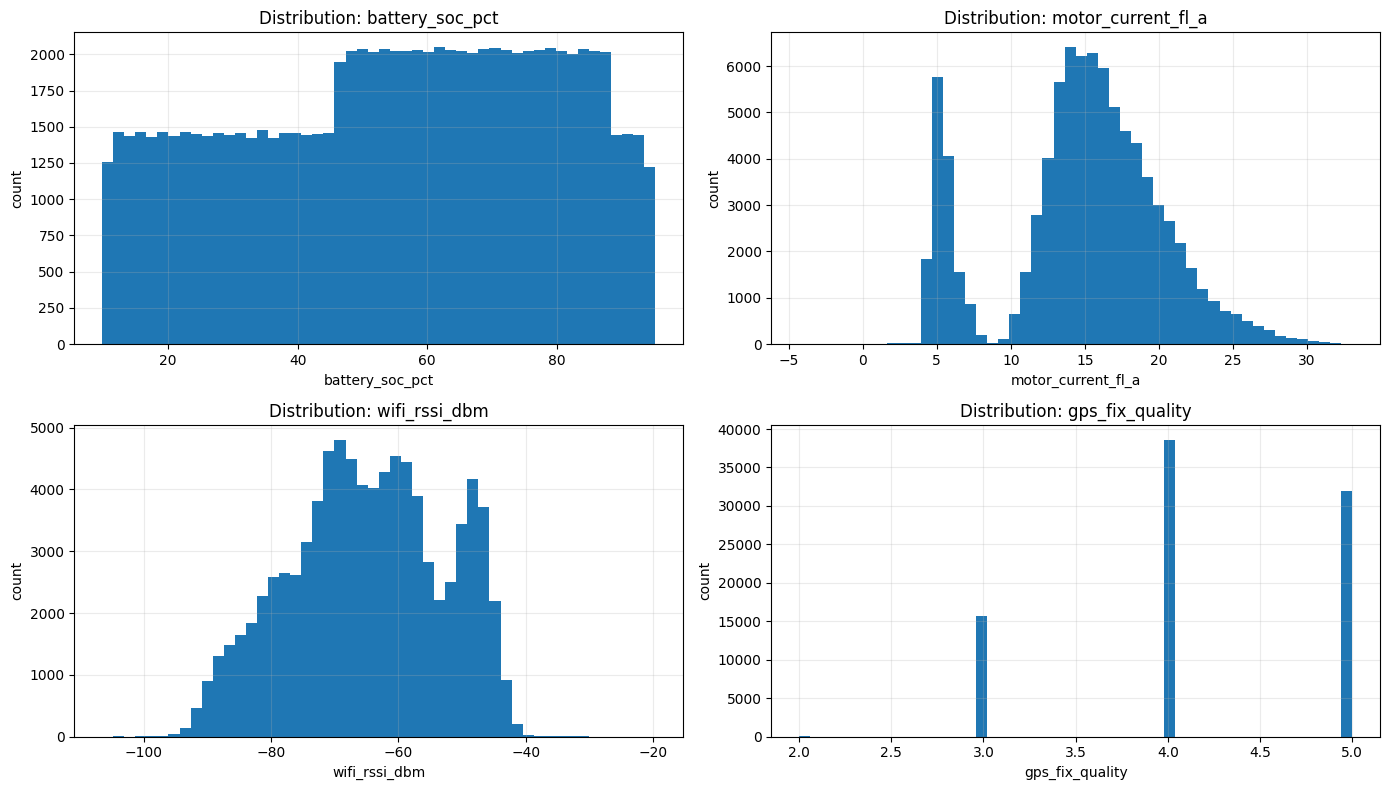

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_cols = ["battery_soc_pct", "motor_current_fl_a", "wifi_rssi_dbm", "gps_fix_quality"]

for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df[col].dropna(), bins=50)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

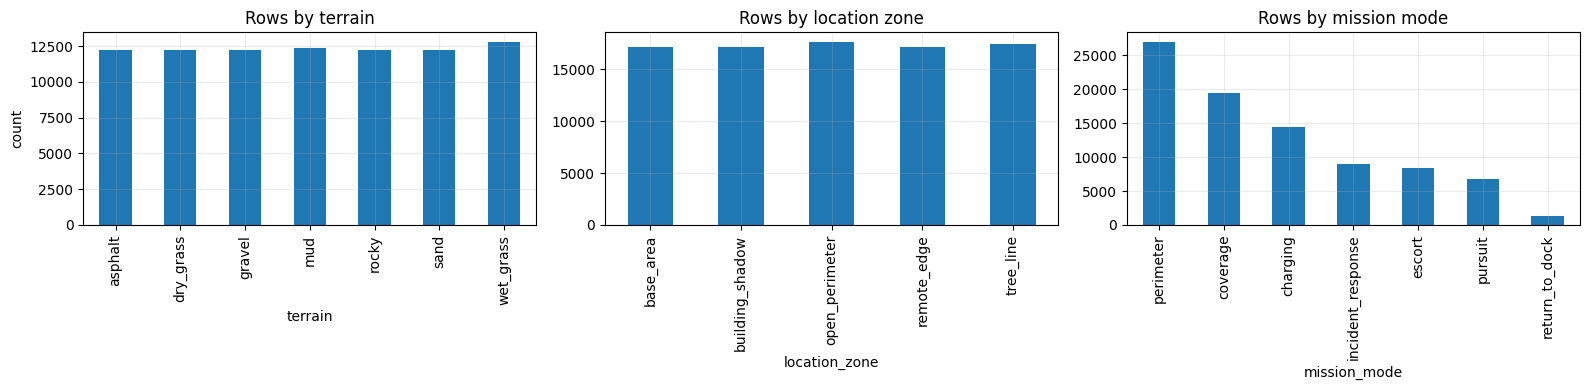

In [9]:
# Categorical coverage
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["terrain"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Rows by terrain")
axes[0].set_ylabel("count")

df["location_zone"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Rows by location zone")

df["mission_mode"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=axes[2])
axes[2].set_title("Rows by mission mode")

plt.tight_layout()
plt.show()

## 3. Time-Series Preparation

For stationarity and decomposition, the notebook uses a 1-minute resample. This keeps the analysis fast while preserving the operational cycles generated at 1 Hz.

The original dataset remains loaded at 1 Hz for missingness and correlation checks.

In [10]:
# Build a 1-minute panel by robot.
df_ts = df.set_index("timestamp").sort_index()

resample_cols = [
    "battery_soc_pct",
    "battery_voltage_v",
    "motor_current_fl_a",
    "motor_current_fr_a",
    "motor_current_rl_a",
    "motor_current_rr_a",
    "motor_temp_c",
    "wifi_rssi_dbm",
    "gps_fix_quality",
    "gps_hdop",
    "gps_num_sats",
    "speed_mps",
    "imu_accel_z_mps2",
    "task_success_flag",
    "benign_noise_flag",
    "missingness_flag",
]

minute_panel = (
    df_ts.groupby("robot_id")[resample_cols]
    .resample("1min")
    .mean()
    .reset_index()
    .sort_values(["robot_id", "timestamp"])
)

minute_panel["motor_current_mean_a"] = minute_panel[
    ["motor_current_fl_a", "motor_current_fr_a", "motor_current_rl_a", "motor_current_rr_a"]
].mean(axis=1)

minute_panel["motor_current_imbalance_a"] = (
    minute_panel[["motor_current_fl_a", "motor_current_rl_a"]].mean(axis=1)
    - minute_panel[["motor_current_fr_a", "motor_current_rr_a"]].mean(axis=1)
)

print("Minute panel shape:", minute_panel.shape)
display(minute_panel.head())

Minute panel shape: (1440, 20)


,robot_id,timestamp,battery_soc_pct,battery_voltage_v,motor_current_fl_a,motor_current_fr_a,motor_current_rl_a,motor_current_rr_a,motor_temp_c,wifi_rssi_dbm,gps_fix_quality,gps_hdop,gps_num_sats,speed_mps,imu_accel_z_mps2,task_success_flag,benign_noise_flag,missingness_flag,motor_current_mean_a,motor_current_imbalance_a
0,AR-004,2026-07-01 00:00:00+00:00,88.328521,49.305618,22.744470,23.055355,22.131773,22.403261,45.791258,-57.519338,4.694915,0.750843,17.350000,1.093877,9.845128,0.983333,0.000000,0.016667,22.583715,-0.291186
1,AR-004,2026-07-01 00:01:00+00:00,88.137946,49.258748,24.177168,23.166548,23.942107,22.976060,46.015810,-56.583422,4.683333,0.774636,17.366667,1.150606,9.815391,1.000000,0.000000,0.016667,23.565471,0.988333
2,AR-004,2026-07-01 00:02:00+00:00,87.951578,49.271772,22.252528,21.532183,22.977894,22.299221,45.546251,-56.180006,4.683333,0.757341,17.133333,1.085414,9.771725,1.000000,0.050000,0.000000,22.265456,0.699509
3,AR-004,2026-07-01 00:03:00+00:00,87.785985,49.228397,23.143807,23.573036,22.955398,23.215385,45.655679,-56.366594,4.750000,0.709268,17.500000,1.148637,9.824128,1.000000,0.016667,0.000000,23.221906,-0.344608
4,AR-004,2026-07-01 00:04:00+00:00,87.605805,49.221101,22.358198,23.467745,22.050812,23.098800,45.117037,-55.139969,4.700000,0.753760,17.566667,1.088752,9.815492,1.000000,0.033333,0.000000,22.743889,-1.078768


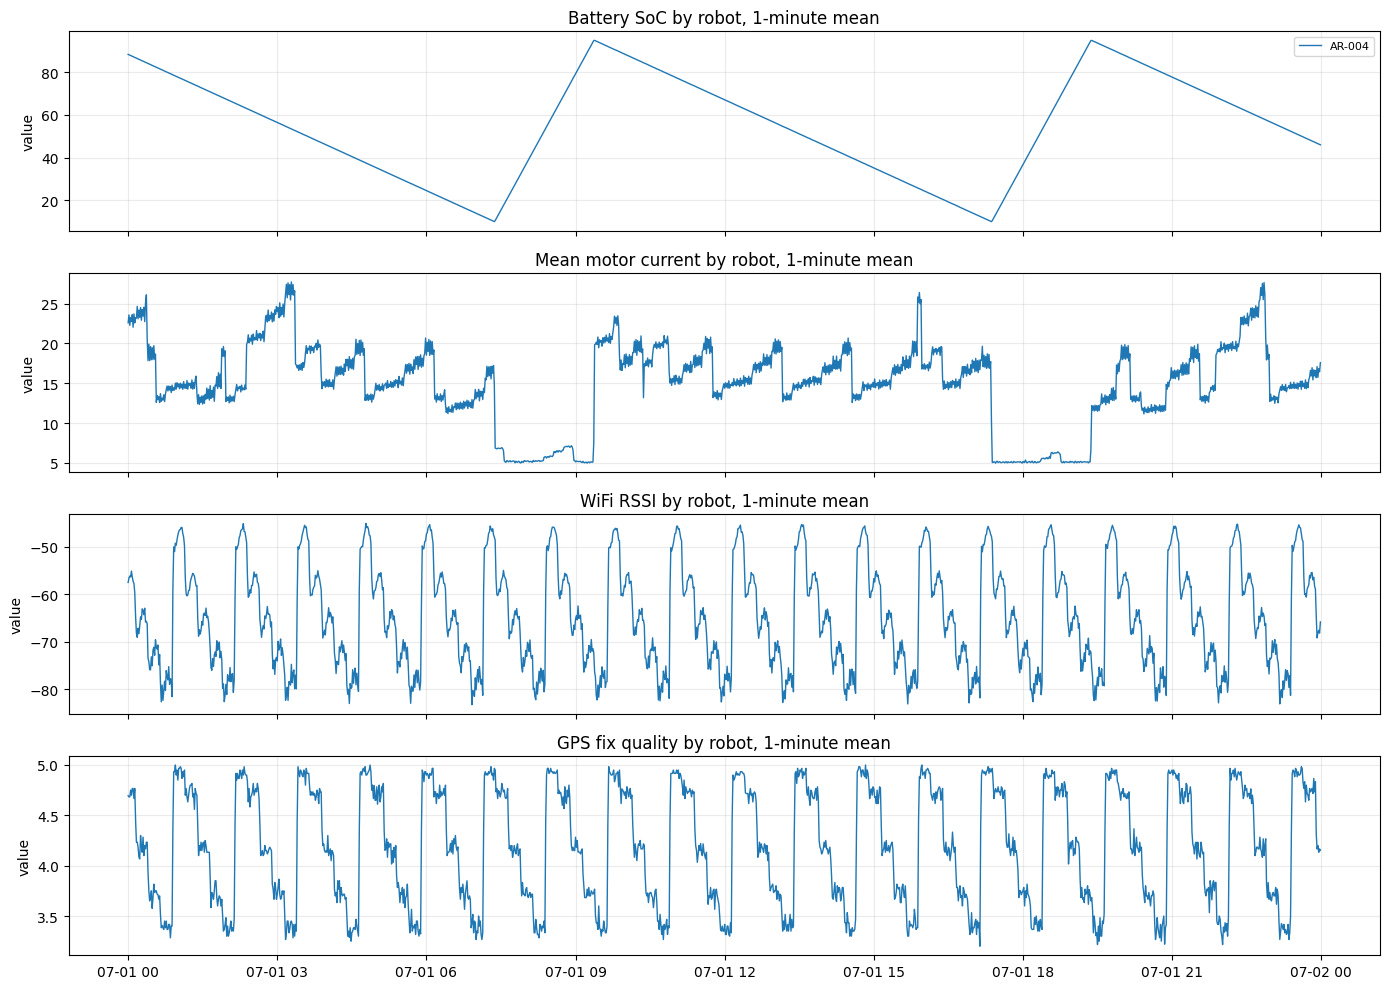

In [11]:
# Quick time series view for all units.
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for robot, g in minute_panel.groupby("robot_id"):
    axes[0].plot(g["timestamp"], g["battery_soc_pct"], linewidth=1, label=robot)
    axes[1].plot(g["timestamp"], g["motor_current_mean_a"], linewidth=1)
    axes[2].plot(g["timestamp"], g["wifi_rssi_dbm"], linewidth=1)
    axes[3].plot(g["timestamp"], g["gps_fix_quality"], linewidth=1)

axes[0].set_title("Battery SoC by robot, 1-minute mean")
axes[1].set_title("Mean motor current by robot, 1-minute mean")
axes[2].set_title("WiFi RSSI by robot, 1-minute mean")
axes[3].set_title("GPS fix quality by robot, 1-minute mean")
axes[0].legend(ncol=5, fontsize=8)

for ax in axes:
    ax.set_ylabel("value")

plt.tight_layout()
plt.show()

## 4. ADF Stationarity Tests

Interpretation used here:

- Null hypothesis: the series has a unit root.
- If `p_value <= 0.05`, reject the unit-root null and mark the series as stationary under this test setup.
- If `p_value > 0.05`, do not reject the unit-root null.

The test is run on 1-minute data for selected operational signals. For trend-like signals such as `battery_soc_pct`, the level series may be non-stationary over a charge/discharge cycle, so the notebook also tests the first difference.

In [12]:
def run_adf(series: pd.Series, regression: str = "c", autolag: str = "AIC") -> dict:
    """Run ADF safely on a numeric series."""
    x = series.astype(float).replace([np.inf, -np.inf], np.nan).dropna()

    # ADF needs enough variation and observations.
    if len(x) < 50 or x.nunique() < 3:
        return {
            "adf_stat": np.nan,
            "p_value": np.nan,
            "used_lag": np.nan,
            "nobs": len(x),
            "stationary_5pct": False,
            "note": "insufficient variation or observations",
        }

    try:
        result = adfuller(x, regression=regression, autolag=autolag)
        adf_stat, p_value, used_lag, nobs, critical_values, icbest = result
        return {
            "adf_stat": adf_stat,
            "p_value": p_value,
            "used_lag": used_lag,
            "nobs": nobs,
            "stationary_5pct": bool(p_value <= 0.05),
            "crit_1pct": critical_values.get("1%"),
            "crit_5pct": critical_values.get("5%"),
            "crit_10pct": critical_values.get("10%"),
            "icbest": icbest,
            "note": "",
        }
    except Exception as e:
        return {
            "adf_stat": np.nan,
            "p_value": np.nan,
            "used_lag": np.nan,
            "nobs": len(x),
            "stationary_5pct": False,
            "note": repr(e),
        }


adf_signals = [
    "battery_soc_pct",
    "battery_voltage_v",
    "motor_current_mean_a",
    "motor_temp_c",
    "wifi_rssi_dbm",
    "gps_hdop",
    "speed_mps",
    "imu_accel_z_mps2",
]

records = []
for robot, g in minute_panel.groupby("robot_id"):
    g = g.sort_values("timestamp")
    for col in adf_signals:
        level = run_adf(g[col], regression="c", autolag="AIC")
        level.update({"robot_id": robot, "signal": col, "transform": "level"})
        records.append(level)

        diff = run_adf(g[col].diff(), regression="c", autolag="AIC")
        diff.update({"robot_id": robot, "signal": col, "transform": "first_diff"})
        records.append(diff)

adf_df = pd.DataFrame(records)
adf_df = adf_df[
    ["robot_id", "signal", "transform", "adf_stat", "p_value", "used_lag", "nobs",
     "stationary_5pct", "crit_1pct", "crit_5pct", "crit_10pct", "icbest", "note"]
].sort_values(["signal", "robot_id", "transform"])

display(adf_df)

,robot_id,signal,transform,adf_stat,p_value,used_lag,nobs,stationary_5pct,crit_1pct,crit_5pct,crit_10pct,icbest,note
1,AR-004,battery_soc_pct,first_diff,-2.627756,8.739525e-02,2,1436,False,-3.434912,-2.863555,-2.567843,-4370.631966,
0,AR-004,battery_soc_pct,level,-3.816884,2.739216e-03,3,1436,True,-3.434912,-2.863555,-2.567843,-4386.778002,
3,AR-004,battery_voltage_v,first_diff,-4.475213,2.179451e-04,19,1419,True,-3.434967,-2.863579,-2.567856,-3273.159812,
2,AR-004,battery_voltage_v,level,-2.497701,1.160347e-01,20,1419,False,-3.434967,-2.863579,-2.567856,-3280.586594,
11,AR-004,gps_hdop,first_diff,-31.114589,0.000000e+00,0,1438,True,-3.434906,-2.863552,-2.567841,-2268.633199,
10,AR-004,gps_hdop,level,-10.482699,1.202211e-18,24,1415,True,-3.434980,-2.863585,-2.567859,-2354.992604,
15,AR-004,imu_accel_z_mps2,first_diff,-13.425829,4.103990e-25,24,1414,True,-3.434983,-2.863586,-2.567859,-7540.853251,
14,AR-004,imu_accel_z_mps2,level,-39.060107,0.000000e+00,0,1439,True,-3.434902,-2.863551,-2.567840,-7629.099757,
5,AR-004,motor_current_mean_a,first_diff,-10.001750,1.876280e-17,18,1420,True,-3.434963,-2.863578,-2.567855,3917.601266,
4,AR-004,motor_current_mean_a,level,-3.601875,5.725279e-03,19,1420,True,-3.434963,-2.863578,-2.567855,3912.216419,


In [13]:
# Compact ADF pass-rate summary.
adf_summary = (
    adf_df.groupby(["signal", "transform"], as_index=False)
    .agg(
        robots_tested=("robot_id", "nunique"),
        stationary_robots=("stationary_5pct", "sum"),
        median_p_value=("p_value", "median"),
        max_p_value=("p_value", "max"),
    )
)
adf_summary["stationary_share"] = adf_summary["stationary_robots"] / adf_summary["robots_tested"]
display(adf_summary.sort_values(["signal", "transform"]))

,signal,transform,robots_tested,stationary_robots,median_p_value,max_p_value,stationary_share
0,battery_soc_pct,first_diff,1,0,8.739525e-02,8.739525e-02,0.0
1,battery_soc_pct,level,1,1,2.739216e-03,2.739216e-03,1.0
2,battery_voltage_v,first_diff,1,1,2.179451e-04,2.179451e-04,1.0
3,battery_voltage_v,level,1,0,1.160347e-01,1.160347e-01,0.0
4,gps_hdop,first_diff,1,1,0.000000e+00,0.000000e+00,1.0
5,gps_hdop,level,1,1,1.202211e-18,1.202211e-18,1.0
6,imu_accel_z_mps2,first_diff,1,1,4.103990e-25,4.103990e-25,1.0
7,imu_accel_z_mps2,level,1,1,0.000000e+00,0.000000e+00,1.0
8,motor_current_mean_a,first_diff,1,1,1.876280e-17,1.876280e-17,1.0
9,motor_current_mean_a,level,1,1,5.725279e-03,5.725279e-03,1.0


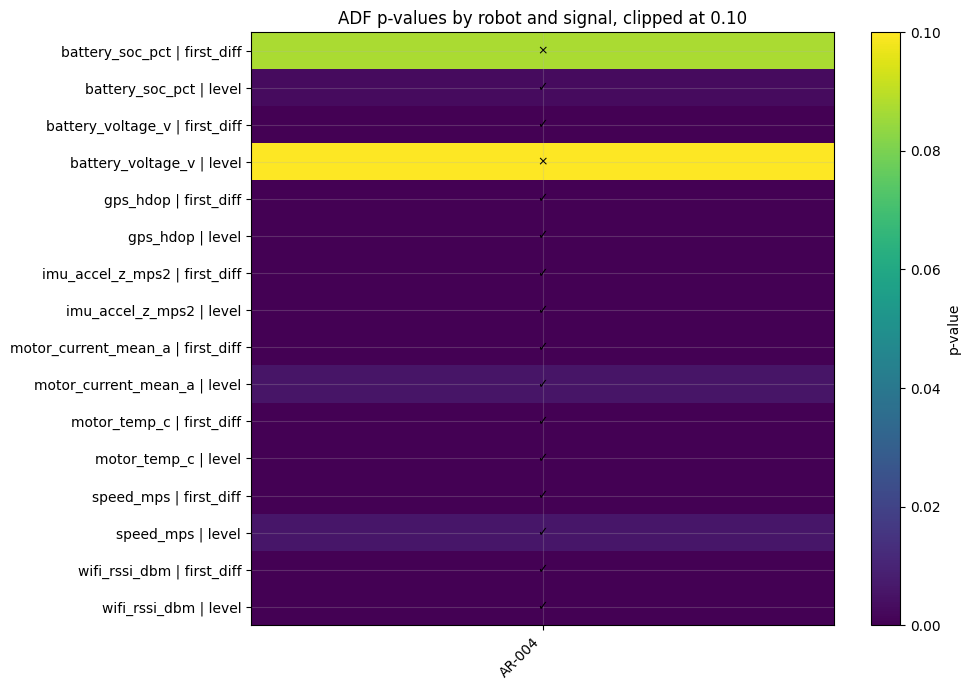

In [14]:
# Visualize ADF p-values. Lower is stronger evidence against a unit root.
pivot_adf = adf_df.pivot_table(
    index=["signal", "transform"],
    columns="robot_id",
    values="p_value",
    aggfunc="first",
)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot_adf.values, aspect="auto", vmin=0, vmax=0.10)

ax.set_xticks(range(len(pivot_adf.columns)))
ax.set_xticklabels(pivot_adf.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_adf.index)))
ax.set_yticklabels([f"{a} | {b}" for a, b in pivot_adf.index])

ax.set_title("ADF p-values by robot and signal, clipped at 0.10")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("p-value")

# Mark the 0.05 decision boundary with cell text.
for i in range(pivot_adf.shape[0]):
    for j in range(pivot_adf.shape[1]):
        val = pivot_adf.iloc[i, j]
        label = "" if pd.isna(val) else ("✓" if val <= 0.05 else "×")
        ax.text(j, i, label, ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### ADF Takeaway

The first-difference rows are often the more important diagnostic for telemetry features that have designed operational cycles, such as battery charge and discharge. A non-stationary level series is not automatically a data problem. It often means the generator is producing realistic trend or cycle behavior that should be handled explicitly in later modeling.

## 5. STL Seasonality Decomposition

The notebook decomposes selected 1-minute signals for one representative robot. Because this sample covers one day, the STL periods are interpreted as **operational cycle periods**, not as long-run calendar seasonality.

Selected periods:

- battery SoC: 600 minutes, approximating the designed 10-hour discharge/charge cycle
- motor current, RSSI, speed: 60 minutes, capturing route and location-level operating cycles

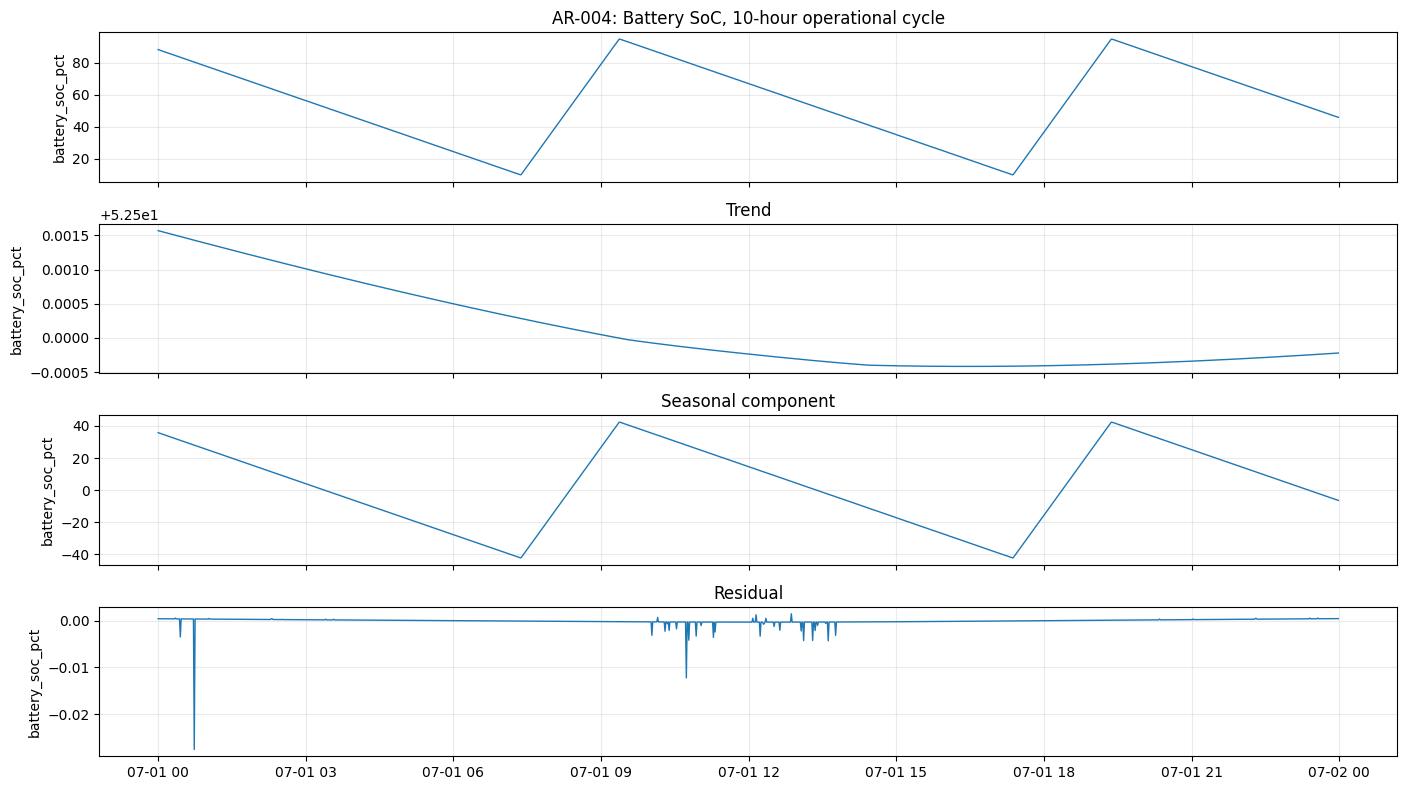

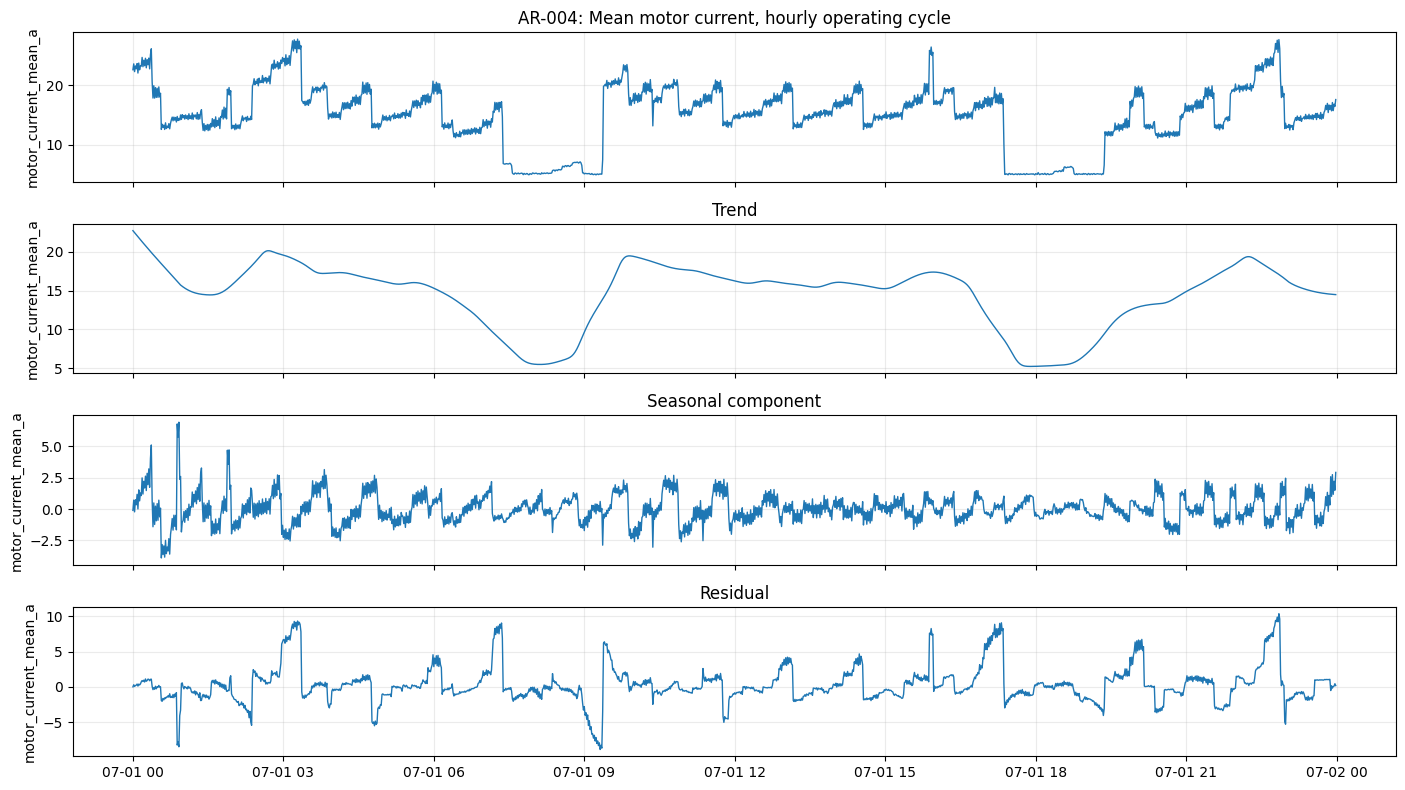

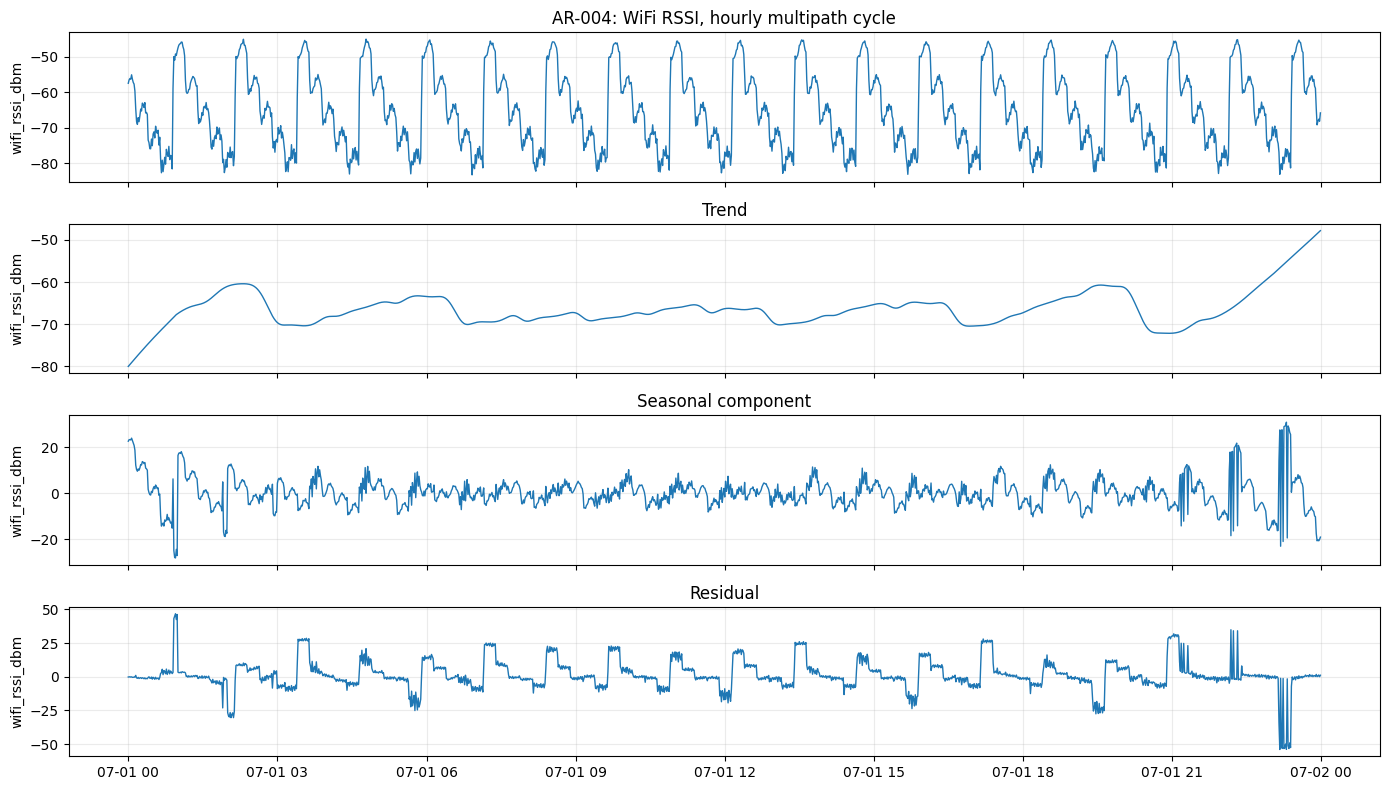

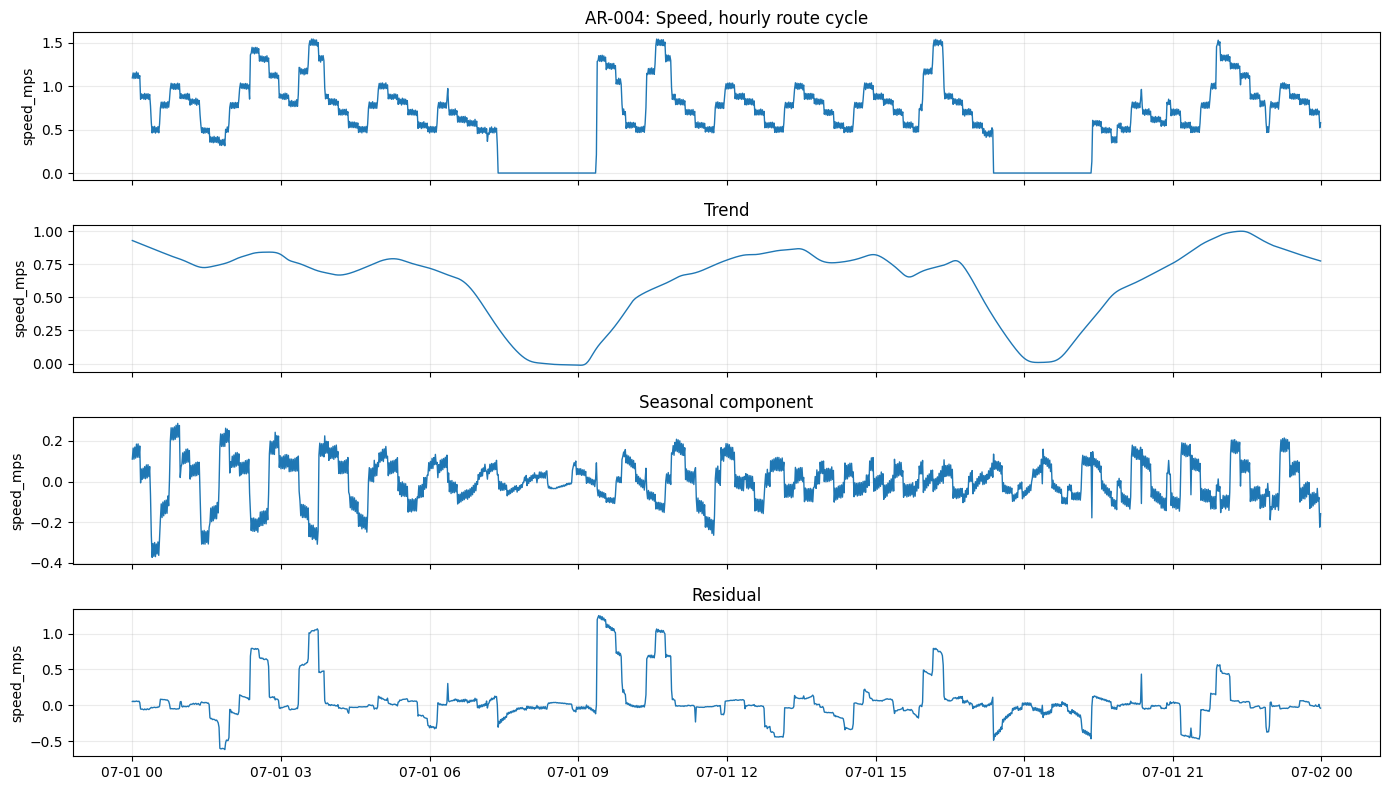

In [15]:
REP_ROBOT = sorted(minute_panel["robot_id"].unique())[0]
rep = minute_panel[minute_panel["robot_id"] == REP_ROBOT].set_index("timestamp").sort_index()

stl_specs = {
    "battery_soc_pct": {"period": 600, "title": "Battery SoC, 10-hour operational cycle"},
    "motor_current_mean_a": {"period": 60, "title": "Mean motor current, hourly operating cycle"},
    "wifi_rssi_dbm": {"period": 60, "title": "WiFi RSSI, hourly multipath cycle"},
    "speed_mps": {"period": 60, "title": "Speed, hourly route cycle"},
}

stl_results = {}

for col, spec in stl_specs.items():
    series = rep[col].astype(float).interpolate(limit_direction="both")
    period = spec["period"]

    stl = STL(series, period=period, robust=True)
    result = stl.fit()
    stl_results[col] = result

    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(series.index, series.values, linewidth=1)
    axes[0].set_title(f"{REP_ROBOT}: {spec['title']}")

    axes[1].plot(series.index, result.trend, linewidth=1)
    axes[1].set_title("Trend")

    axes[2].plot(series.index, result.seasonal, linewidth=1)
    axes[2].set_title("Seasonal component")

    axes[3].plot(series.index, result.resid, linewidth=1)
    axes[3].set_title("Residual")

    for ax in axes:
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [16]:
# STL variance share summary.
stl_summary_rows = []

for col, result in stl_results.items():
    original = rep[col].astype(float).interpolate(limit_direction="both")
    total_var = float(np.nanvar(original.values))
    seasonal_var = float(np.nanvar(result.seasonal))
    trend_var = float(np.nanvar(result.trend))
    resid_var = float(np.nanvar(result.resid))

    stl_summary_rows.append({
        "robot_id": REP_ROBOT,
        "signal": col,
        "period_minutes": stl_specs[col]["period"],
        "total_variance": total_var,
        "trend_variance_share": trend_var / total_var if total_var else np.nan,
        "seasonal_variance_share": seasonal_var / total_var if total_var else np.nan,
        "residual_variance_share": resid_var / total_var if total_var else np.nan,
    })

stl_summary_df = pd.DataFrame(stl_summary_rows)
display(stl_summary_df)

,robot_id,signal,period_minutes,total_variance,trend_variance_share,seasonal_variance_share,residual_variance_share
0,AR-004,battery_soc_pct,600,556.631519,6.326876e-10,0.999996,1.452030e-09
1,AR-004,motor_current_mean_a,60,26.996108,6.259009e-01,0.048129,2.512135e-01
2,AR-004,wifi_rssi_dbm,60,118.322304,1.512050e-01,0.384428,1.054257e+00
3,AR-004,speed_mps,60,0.151214,5.206306e-01,0.074937,5.497538e-01


## 6. Pairwise Correlation Structure

This section uses the 1-minute panel to reduce autocorrelation-driven visual density and focus on operational relationships across sensors. Correlations should be interpreted as descriptive structure, not causal relationships.

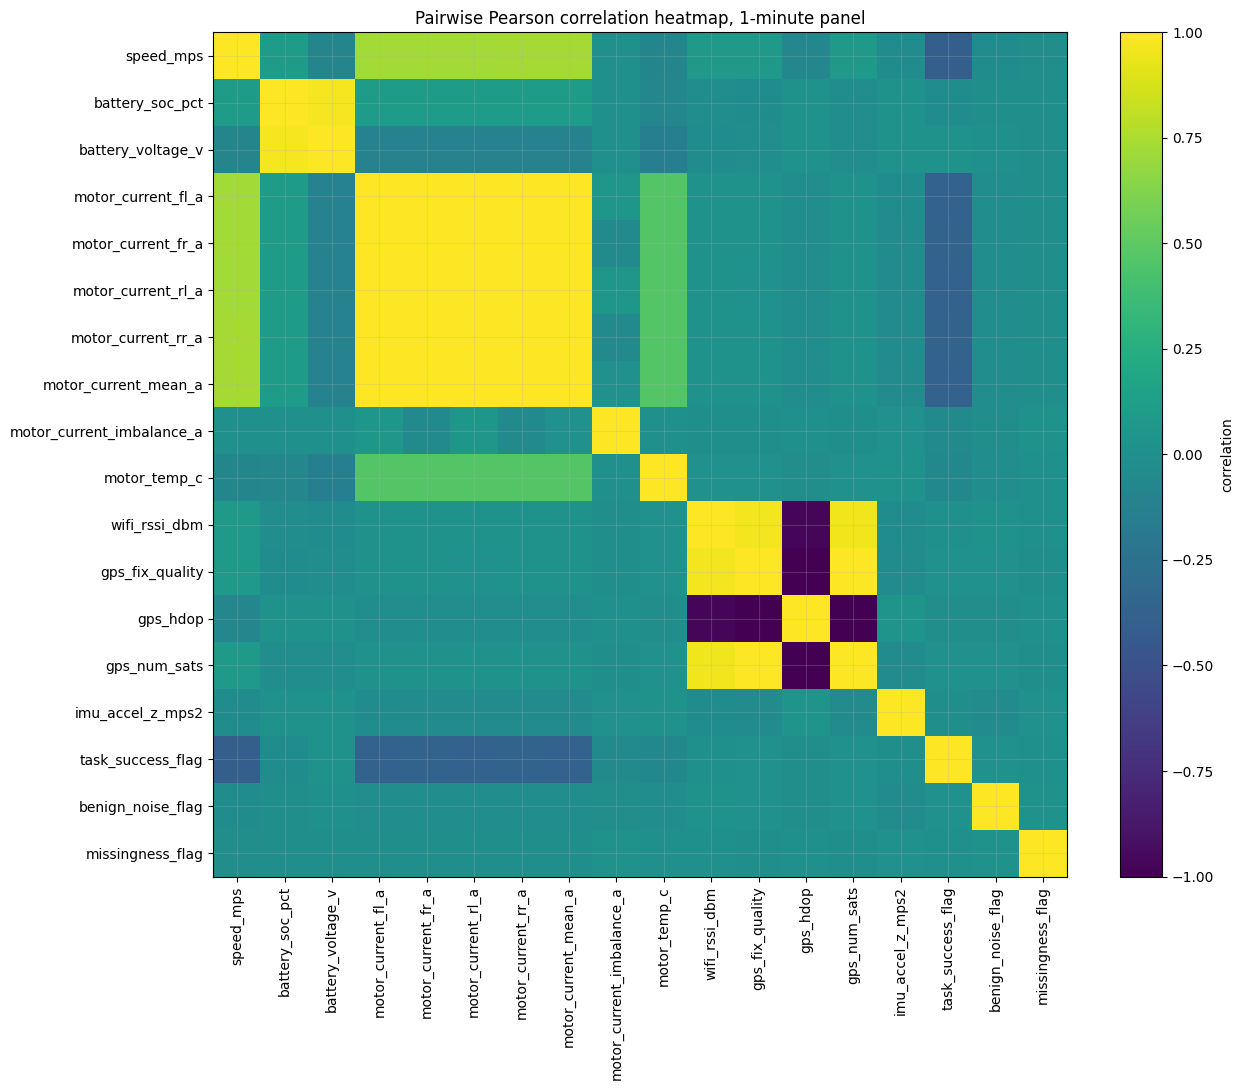

,speed_mps,battery_soc_pct,battery_voltage_v,motor_current_fl_a,motor_current_fr_a,motor_current_rl_a,motor_current_rr_a,motor_current_mean_a,motor_current_imbalance_a,motor_temp_c,wifi_rssi_dbm,gps_fix_quality,gps_hdop,gps_num_sats,imu_accel_z_mps2,task_success_flag,benign_noise_flag,missingness_flag
speed_mps,1.000,0.100,-0.087,0.726,0.726,0.727,0.727,0.728,0.001,-0.085,0.081,0.071,-0.071,0.072,-0.026,-0.391,-0.029,-0.011
battery_soc_pct,0.100,1.000,0.972,0.095,0.095,0.096,0.096,0.096,0.001,-0.074,-0.023,-0.026,0.027,-0.020,0.020,-0.028,-0.005,-0.001
battery_voltage_v,-0.087,0.972,1.000,-0.113,-0.113,-0.113,-0.113,-0.113,0.001,-0.135,-0.024,-0.023,0.023,-0.017,0.028,0.025,0.005,-0.005
motor_current_fl_a,0.726,0.095,-0.113,1.000,0.995,0.999,0.993,0.998,0.059,0.468,0.023,0.016,-0.016,0.018,-0.031,-0.370,-0.021,-0.003
motor_current_fr_a,0.726,0.095,-0.113,0.995,1.000,0.993,0.999,0.998,-0.042,0.467,0.023,0.016,-0.016,0.018,-0.032,-0.366,-0.020,-0.006
motor_current_rl_a,0.727,0.096,-0.113,0.999,0.993,1.000,0.995,0.998,0.059,0.468,0.023,0.016,-0.016,0.018,-0.032,-0.369,-0.020,-0.004
motor_current_rr_a,0.727,0.096,-0.113,0.993,0.999,0.995,1.000,0.998,-0.042,0.468,0.023,0.016,-0.016,0.018,-0.033,-0.365,-0.019,-0.007
motor_current_mean_a,0.728,0.096,-0.113,0.998,0.998,0.998,0.998,1.000,0.008,0.468,0.023,0.016,-0.016,0.018,-0.032,-0.368,-0.020,-0.005
motor_current_imbalance_a,0.001,0.001,0.001,0.059,-0.042,0.059,-0.042,0.008,1.000,0.008,-0.001,-0.001,0.002,-0.003,0.010,-0.043,-0.015,0.031
motor_temp_c,-0.085,-0.074,-0.135,0.468,0.467,0.468,0.468,0.468,0.008,1.000,0.015,0.012,-0.012,0.012,0.018,-0.065,-0.019,0.006


In [17]:
corr_cols = [
    "speed_mps",
    "battery_soc_pct",
    "battery_voltage_v",
    "motor_current_fl_a",
    "motor_current_fr_a",
    "motor_current_rl_a",
    "motor_current_rr_a",
    "motor_current_mean_a",
    "motor_current_imbalance_a",
    "motor_temp_c",
    "wifi_rssi_dbm",
    "gps_fix_quality",
    "gps_hdop",
    "gps_num_sats",
    "imu_accel_z_mps2",
    "task_success_flag",
    "benign_noise_flag",
    "missingness_flag",
]

corr_df = minute_panel[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_df.values, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)
ax.set_title("Pairwise Pearson correlation heatmap, 1-minute panel")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("correlation")

plt.tight_layout()
plt.show()

display(corr_df.round(3))

In [18]:
# High-correlation pairs, excluding self-correlation and duplicates.
corr_pairs = (
    corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_a", "feature_b", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

high_corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False).head(20)
display(high_corr_pairs)

,feature_a,feature_b,correlation,abs_correlation
132,gps_fix_quality,gps_hdop,-0.999645,0.999645
63,motor_current_fr_a,motor_current_rr_a,0.998523,0.998523
49,motor_current_fl_a,motor_current_rl_a,0.998501,0.998501
87,motor_current_rr_a,motor_current_mean_a,0.998362,0.998362
51,motor_current_fl_a,motor_current_mean_a,0.998354,0.998354
76,motor_current_rl_a,motor_current_mean_a,0.998349,0.998349
64,motor_current_fr_a,motor_current_mean_a,0.998348,0.998348
75,motor_current_rl_a,motor_current_rr_a,0.994878,0.994878
48,motor_current_fl_a,motor_current_fr_a,0.994855,0.994855
50,motor_current_fl_a,motor_current_rr_a,0.993477,0.993477


### Correlation Takeaway

Expected structural relationships include:

- strong positive correlation among the four drive-motor currents
- positive relationship between speed and motor current
- relationship between battery voltage and battery SoC, with voltage also affected by load
- negative relationship between GPS HDOP and GPS fix quality
- RSSI and GPS quality may co-move in low-visibility or multipath-heavy location zones

## 7. Missingness Pattern Analysis

The generator intentionally injects a light baseline missingness rate to create realistic telemetry quality issues. This section checks whether missingness stays low overall, whether it clusters by robot, and whether specific sensor channels are more affected.

,column,missing_rate
38,gps_fix_quality,0.000775
39,gps_hdop,0.000741
36,wifi_rssi_dbm,0.000718
27,imu_gyro_z_rps,0.000660
23,imu_accel_y_mps2,0.000648
22,imu_accel_x_mps2,0.000544
6,mission_mode,0.000000
7,terrain,0.000000
0,schema_version,0.000000
1,timestamp,0.000000


/tmp/ipykernel_3698/1871442174.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_missing["column"], rotation=90)


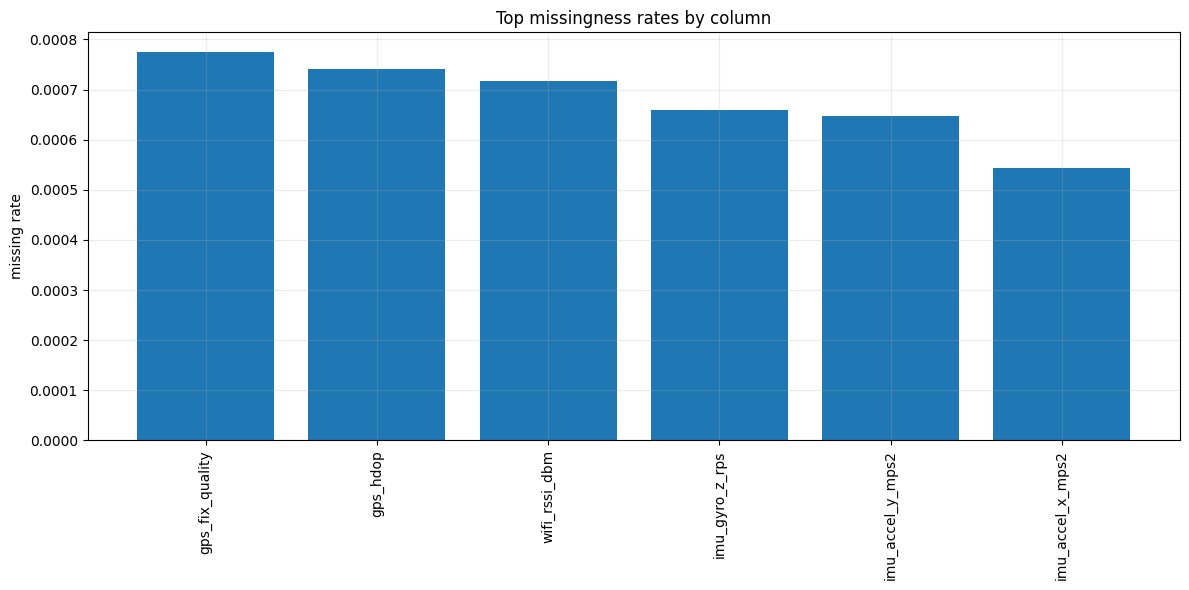

In [19]:
missing_by_col = (
    df.isna().mean()
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_rate", ascending=False)
)

display(missing_by_col.head(25))

fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing_by_col[missing_by_col["missing_rate"] > 0].head(20)
ax.bar(top_missing["column"], top_missing["missing_rate"])
ax.set_title("Top missingness rates by column")
ax.set_ylabel("missing rate")
ax.set_xticklabels(top_missing["column"], rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3698/2867061724.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isna().mean().mean())


,robot_id,mean_cell_missing_rate
0,AR-004,0.000089


,robot_id,wifi_rssi_dbm,gps_fix_quality,gps_hdop,imu_accel_x_mps2,imu_accel_y_mps2,imu_gyro_z_rps
0,AR-004,0.000718,0.000775,0.000741,0.000544,0.000648,0.00066


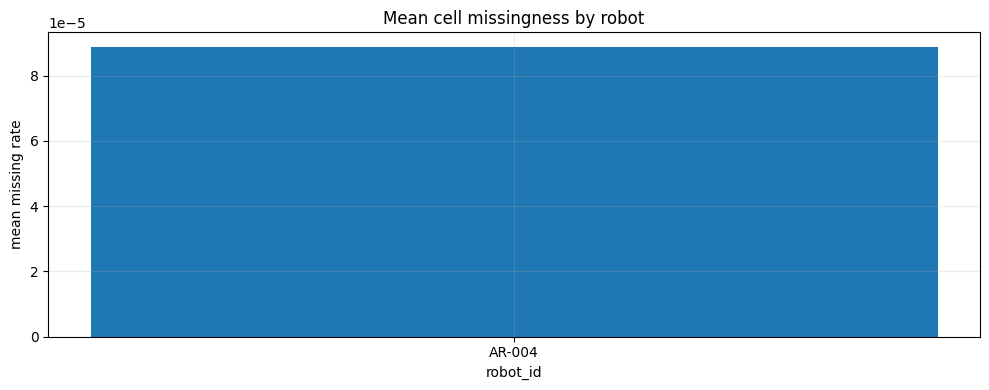

In [20]:
missing_by_robot = (
    df.groupby("robot_id")
    .apply(lambda g: g.isna().mean().mean())
    .rename("mean_cell_missing_rate")
    .reset_index()
)

sensor_missing_cols = [
    "wifi_rssi_dbm",
    "gps_fix_quality",
    "gps_hdop",
    "imu_accel_x_mps2",
    "imu_accel_y_mps2",
    "imu_gyro_z_rps",
]

sensor_missing_by_robot = (
    df.groupby("robot_id")[sensor_missing_cols]
    .apply(lambda g: g.isna().mean())
    .reset_index()
)

display(missing_by_robot)
display(sensor_missing_by_robot)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing_by_robot["robot_id"], missing_by_robot["mean_cell_missing_rate"])
ax.set_title("Mean cell missingness by robot")
ax.set_xlabel("robot_id")
ax.set_ylabel("mean missing rate")
plt.tight_layout()
plt.show()

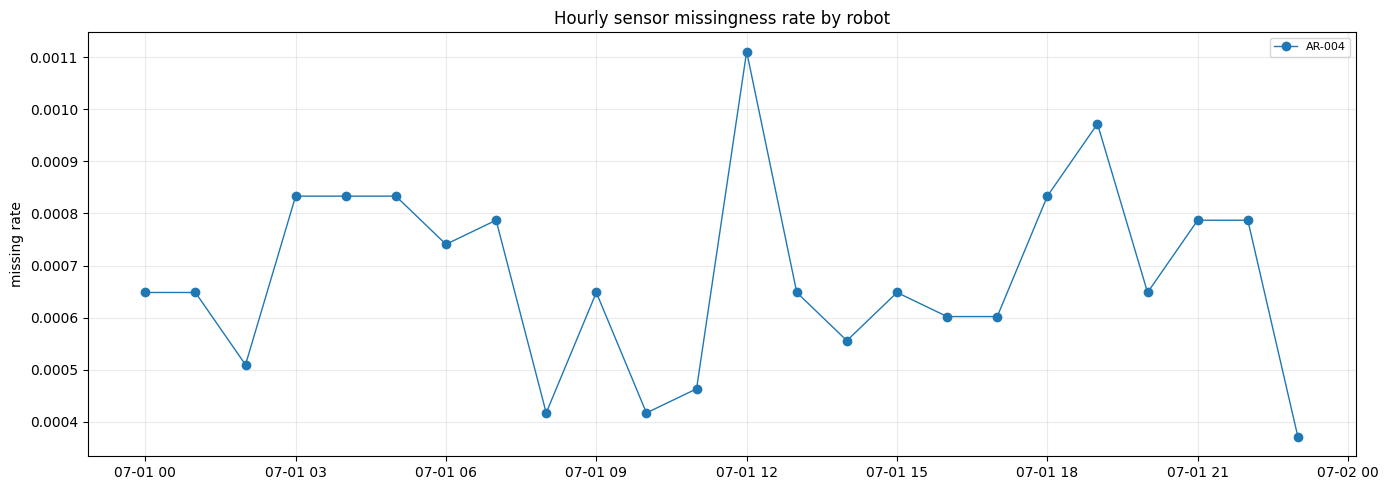

,robot_id,timestamp,hourly_missing_rate
0,AR-004,2026-07-01 00:00:00+00:00,0.000648
1,AR-004,2026-07-01 01:00:00+00:00,0.000648
2,AR-004,2026-07-01 02:00:00+00:00,0.000509
3,AR-004,2026-07-01 03:00:00+00:00,0.000833
4,AR-004,2026-07-01 04:00:00+00:00,0.000833
5,AR-004,2026-07-01 05:00:00+00:00,0.000833
6,AR-004,2026-07-01 06:00:00+00:00,0.000741
7,AR-004,2026-07-01 07:00:00+00:00,0.000787
8,AR-004,2026-07-01 08:00:00+00:00,0.000417
9,AR-004,2026-07-01 09:00:00+00:00,0.000648


In [21]:
# Hourly missingness pattern by robot.
# This explicit groupby is compatible across pandas versions.
hourly_missing = (
    df.assign(hour=df["timestamp"].dt.floor("h"))
    .groupby(["robot_id", "hour"])[sensor_missing_cols]
    .apply(lambda g: float(g.isna().to_numpy().mean()))
    .reset_index(name="hourly_missing_rate")
    .rename(columns={"hour": "timestamp"})
)

fig, ax = plt.subplots(figsize=(14, 5))
for robot, g in hourly_missing.groupby("robot_id"):
    ax.plot(g["timestamp"], g["hourly_missing_rate"], marker="o", linewidth=1, label=robot)

ax.set_title("Hourly sensor missingness rate by robot")
ax.set_ylabel("missing rate")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

display(hourly_missing.head(15))

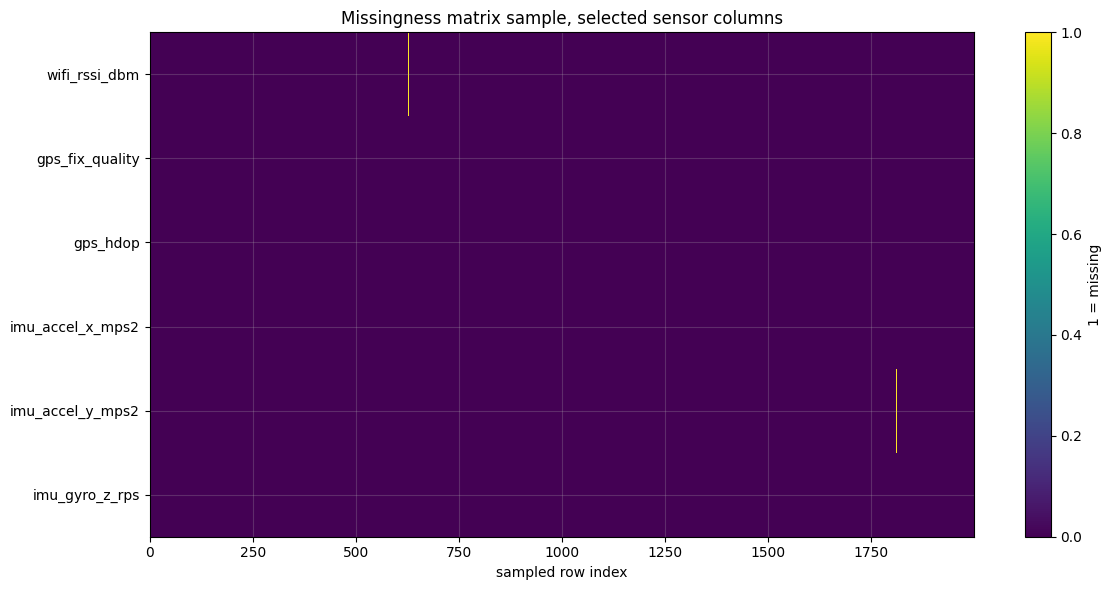

In [22]:
# Missingness matrix for a compact time slice.
# To avoid plotting all 432,000 rows, use the first 2,000 rows per robot and selected columns.
matrix_cols = ["robot_id", "timestamp"] + sensor_missing_cols + ["missingness_flag", "benign_noise_flag"]
matrix_sample = (
    df[matrix_cols]
    .groupby("robot_id", group_keys=False)
    .head(2000)
    .reset_index(drop=True)
)

missing_matrix = matrix_sample[sensor_missing_cols].isna().astype(int).values

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(missing_matrix.T, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
ax.set_title("Missingness matrix sample, selected sensor columns")
ax.set_xlabel("sampled row index")
ax.set_yticks(range(len(sensor_missing_cols)))
ax.set_yticklabels(sensor_missing_cols)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("1 = missing")
plt.tight_layout()
plt.show()

## 8. Compact EDA Findings

- The medium sample contains five synthetic Rover units over one day at 1 Hz, matching the intended `5 × 86,400 = 432,000` row structure.
- Battery SoC shows visible operational charge and discharge cycles, which is expected from the generator design and should not be treated as a fault.
- Motor current is structured by speed, terrain, and thermal drift, producing strong within-drive correlations and useful cross-sensor relationships for later feature engineering.
- WiFi RSSI varies by location-zone and multipath assumptions, while GPS quality and HDOP show the expected inverse relationship.
- ADF results should be read feature by feature. Trend/cycle variables may be non-stationary in level form, while first differences are more appropriate for later anomaly features.
- STL decomposition confirms that selected telemetry streams contain separable trend, seasonal, and residual components at operational-cycle periods.
- Missingness is low and intentionally benign, but it is still useful for testing EDA and later model robustness. Missingness should be tracked by both robot and sensor channel.